In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 Cell 0: Initial Setup & Data Loading

In [ ]:
print("--- Step 1: Uninstalling conflicting default packages... ---")
!pip uninstall -y tensorflow numpy

print("\n--- Step 2: Installing compatible N2V / CSBDeep / TensorFlow stack... ---")
# Added tf-keras and updated TF to 2.17.1 to prevent clashes while finding a valid distribution
# Downgraded jax and jaxlib to resolve the ml_dtypes conflict with TensorFlow 2.17.1
!pip install --quiet "tensorflow==2.17.1" "tf-keras" "csbdeep==0.7.4" "n2v==0.3.3" "jax==0.4.30" "jaxlib==0.4.30"

print("\n--- Step 3: Installing other utilities... ---")
!pip install --quiet tifffile matplotlib tqdm

print("\n\n✅ All installations complete. Please RESTART the session now.")


--- Step 1: Uninstalling conflicting default packages... ---
Found existing installation: numpy 2.5.1
Uninstalling numpy-2.5.1:
  Successfully uninstalled numpy-2.5.1

--- Step 2: Installing compatible N2V / CSBDeep / TensorFlow stack... ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 MB 30.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
dopamine-rl 4.1.2 requires tf-keras>=2.18.0, but you have tf-keras 2.17.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.17.1 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, bu

In [ ]:
import os
# CRITICAL: Force TensorFlow 2.16+ to use legacy Keras 2 to maintain compatibility with N2V
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import sys
import shutil
import numpy as np
import tifffile
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import re

# These are the specific imports for N2V
from n2v.models import N2VConfig, N2V
from csbdeep.utils import plot_history

print(f"Changed working directory to: {os.getcwd()}")

def pad_to_divisible(image_stack, divisor=16):
    num_frames, h, w = image_stack.shape
    pad_h = (divisor - h % divisor) % divisor
    pad_w = (divisor - w % divisor) % divisor
    if pad_h == 0 and pad_w == 0: return image_stack, (0, 0, 0, 0)
    pad_top, pad_bottom = pad_h // 2, pad_h - (pad_h // 2)
    pad_left, pad_right = pad_w // 2, pad_w - (pad_w // 2)
    print(f"Padding HxW from {h}x{w} to {h+pad_h}x{w+pad_w}.")
    padded_stack = np.pad(image_stack, ((0, 0), (pad_top, pad_bottom), (pad_left, pad_right)), mode='reflect')
    return padded_stack, (pad_top, pad_bottom, pad_left, pad_right)

def crop_padded_stack(padded_stack, spatial_pads):
    if not any(spatial_pads): return padded_stack
    pad_top, pad_bottom, pad_left, pad_right = spatial_pads
    h_new, w_new = padded_stack.shape[1], padded_stack.shape[2]
    crop_y_end = h_new - pad_bottom if pad_bottom > 0 else h_new
    crop_x_end = w_new - pad_right if pad_right > 0 else w_new
    return padded_stack[:, pad_top:crop_y_end, pad_left:crop_x_end]

TRAIN_TIFF_PATH = "/content/drive/MyDrive/DATA_ROOT/exp_data2/Cy3_Best/Cy3_Best.tif"


"""
TEST_TIFF_PATHS = [
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/30_Green/30_Green.tif",
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/29_Green/29_Green.tif",
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/20_Green/20_Green.tif",
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/19_Green/19_Green.tif",
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/Cy3_Best/Cy3_Best.tif"
]
"""
TEST_TIFF_PATHS = [
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_1.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_2.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_3.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_4.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_5.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_6.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_7.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_8.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_9.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_10.00.tif"
]


OUTPUT_DIR = "/content/drive/MyDrive/DATA_ROOT/exp_data3"
os.makedirs(OUTPUT_DIR, exist_ok=True)


print(f"Loading TRAINING video from: {TRAIN_TIFF_PATH}")
try:
    training_frames = tifffile.imread(TRAIN_TIFF_PATH).astype(np.float32)
    print(f"✅ Successfully loaded training stack with shape: {training_frames.shape}")
except Exception as e:
    print(f"❌ Error loading training TIFF file: {e}")
    training_frames = None


Changed working directory to: /content
Loading TRAINING video from: /content/drive/MyDrive/DATA_ROOT/exp_data2/Cy3_Best/Cy3_Best.tif
✅ Successfully loaded training stack with shape: (916, 256, 256)


Cell 2: Train the N2V Model


--- Training Noise2Void (N2V) Model ---
Data split -> Training: (824, 256, 256, 1), Validation: (92, 256, 256, 1)
61 blind-spots will be generated per training patch of size (64, 64).


Preparing validation data: 100%|██████████| 92/92 [00:02<00:00, 33.53it/s]


Epoch 1/50
100/100 [==============================] - 44s 388ms/step - loss: 0.7417 - n2v_mse: 1.0293 - n2v_abs: 0.7417 - val_loss: 0.7095 - val_n2v_mse: 0.9601 - val_n2v_abs: 0.7095 - lr: 4.0000e-04
Epoch 2/50
100/100 [==============================] - 36s 365ms/step - loss: 0.7225 - n2v_mse: 0.9682 - n2v_abs: 0.7225 - val_loss: 0.6982 - val_n2v_mse: 0.9085 - val_n2v_abs: 0.6983 - lr: 4.0000e-04
Epoch 3/50
100/100 [==============================] - 37s 370ms/step - loss: 0.7181 - n2v_mse: 0.9514 - n2v_abs: 0.7181 - val_loss: 0.6867 - val_n2v_mse: 0.8818 - val_n2v_abs: 0.6868 - lr: 4.0000e-04
Epoch 4/50
100/100 [==============================] - 37s 367ms/step - loss: 0.7149 - n2v_mse: 0.9339 - n2v_abs: 0.7149 - val_loss: 0.6875 - val_n2v_mse: 0.8722 - val_n2v_abs: 0.6876 - lr: 4.0000e-04
Epoch 5/50
100/100 [==============================] - 40s 404ms/step - loss: 0.7099 - n2v_mse: 0.9257 - n2v_abs: 0.7099 - val_loss: 0.6856 - val_n2v_mse: 0.8665 - val_n2v_abs: 0.6856 - lr: 4.0000e-04


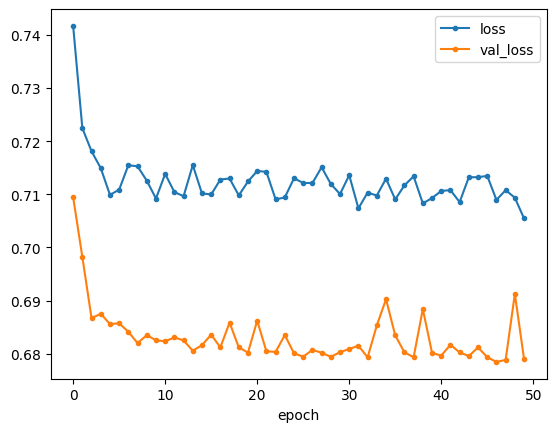

<Figure size 640x480 with 0 Axes>

✅ N2V model training complete. Plot saved to /content/drive/MyDrive/DATA_ROOT/exp_data2/comparison_outputs_final/N2V_model/n2v_trained_on_cy3/training_history.png


In [ ]:
if 'training_frames' in locals() and training_frames is not None:
    print("\n--- Training Noise2Void (N2V) Model ---")

    n2v_model_dir = os.path.join(OUTPUT_DIR, 'N2V_model')
    n2v_model_name = 'n2v_trained_on_cy3'
    if os.path.exists(n2v_model_dir):
        shutil.rmtree(n2v_model_dir)

    X = training_frames[..., np.newaxis]

    split_index = int(len(X) * 0.9)
    X_train, X_val = X[:split_index], X[split_index:]
    print(f"Data split -> Training: {X_train.shape}, Validation: {X_val.shape}")

    config = N2VConfig(X_train, unet_kern_size=3, unet_n_depth=3, unet_n_first=64,
                       train_steps_per_epoch=100, train_epochs=50, train_batch_size=16)

    model = N2V(config=config, name=n2v_model_name, basedir=n2v_model_dir)
    history = model.train(X_train, X_val)

    print("\n--- Saving training history plot ---")
    plot_history(history, ['loss', 'val_loss'])
    plot_path = os.path.join(n2v_model_dir, n2v_model_name, 'training_history.png')
    plt.savefig(plot_path)
    plt.show()
    print(f"✅ N2V model training complete. Plot saved to {plot_path}")
else:
    print("⚠️ Training frames not found. Please run the setup cell (Cell 1) first.")

Cell 3: Denoise Test Videos

In [ ]:
if 'TEST_TIFF_PATHS' in locals():
    print("\n--- Starting N2V Testing ---")

    n2v_model_dir = os.path.join(OUTPUT_DIR, 'N2V_model')
    n2v_model_name = 'n2v_trained_on_cy3'
    try:
        model = N2V(config=None, name=n2v_model_name, basedir=n2v_model_dir)
        print(f"Successfully loaded trained model from: {n2v_model_dir}")
    except Exception as e:
        print(f"❌ Error loading model. Please train the model first. Error: {e}")
        model = None

    if model:
        for test_path in TEST_TIFF_PATHS:
            try:
                print(f"\nProcessing: {os.path.basename(test_path)}")
                test_frames = tifffile.imread(test_path).astype(np.float32)
                base_filename = os.path.splitext(os.path.basename(test_path))[0]
            except Exception as e:
                print(f"  -> ERROR: Could not load {test_path}. Skipping. \n   {e}")
                continue

            padded_test, spatial_pads = pad_to_divisible(test_frames)

            print("  -> Denoising frames...")
            denoised_padded = np.array([model.predict(frame, axes='YX') for frame in tqdm(padded_test)])

            denoised_cropped = crop_padded_stack(denoised_padded, spatial_pads)

            final_output = np.clip(denoised_cropped, 0, 65535).astype(np.uint16)
            output_path = os.path.join(OUTPUT_DIR, f"{base_filename}_denoised_N2V.tif")
            tifffile.imwrite(output_path, final_output, imagej=True)
            print(f"  -> ✅ N2V Denoising Done. Saved to: {output_path}")

else:
    print("⚠️ Test file paths not defined. Please run the setup cell (Cell 1) first.")


--- Starting N2V Testing ---
Loading network weights from 'weights_best.h5'.
Successfully loaded trained model from: /content/drive/MyDrive/DATA_ROOT/exp_data3/N2V_model

Processing: sim_Gauss_Poisson_Est_scale_1.00.tif
  -> Denoising frames...


  0%|          | 0/916 [00:00<?, ?it/s]

1/1 [==============================] - 0s 127ms/step
  -> ✅ N2V Denoising Done. Saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_1.00_denoised_N2V.tif

Processing: sim_Gauss_Poisson_Est_scale_2.00.tif
  -> Denoising frames...


  0%|          | 0/916 [00:00<?, ?it/s]

1/1 [==============================] - 0s 104ms/step
  -> ✅ N2V Denoising Done. Saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_2.00_denoised_N2V.tif

Processing: sim_Gauss_Poisson_Est_scale_3.00.tif
  -> Denoising frames...


...

1/1 [==============================] - 0s 106ms/step
  -> ✅ N2V Denoising Done. Saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_8.00_denoised_N2V.tif

Processing: sim_Gauss_Poisson_Est_scale_9.00.tif
  -> Denoising frames...


  0%|          | 0/916 [00:00<?, ?it/s]

1/1 [==============================] - 0s 104ms/step
  -> ✅ N2V Denoising Done. Saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_9.00_denoised_N2V.tif

Processing: sim_Gauss_Poisson_Est_scale_10.00.tif
  -> Denoising frames...


  0%|          | 0/916 [00:00<?, ?it/s]

1/1 [==============================] - 0s 105ms/step
  -> ✅ N2V Denoising Done. Saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_10.00_denoised_N2V.tif
